/tmp/ipykernel_2220651/3156234621.py:16: FutureWarning: In a future version, xarray will not decode the variable 'average_DT' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  ds_bio = xr.open_dataset(base_dir / "MOM6COBALT_DG_JRA_60yr_raw" / f"hist_control_cobalt_3d_yearly__{year:04d}_{month:02d}.nc", chunks={"time": 1})
/tmp/ipykernel_2220651/3156234621.py:16: FutureWarning: In a future version, xarray will not decode the variable 'time_bnds' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on 


Inferred uniform metrics from hgrid:
  DX ≈ 4.722 km
  DY ≈ 4.722 km
DEBUG vorticity: dv_dx shape (32, 75, 361, 361) du_dy shape (32, 75, 361, 361) zeta shape (32, 75, 361, 361)
DEBUG divergence: du_dx shape (32, 75, 362, 362) dv_dy shape (32, 75, 362, 362) div shape (32, 75, 362, 362)


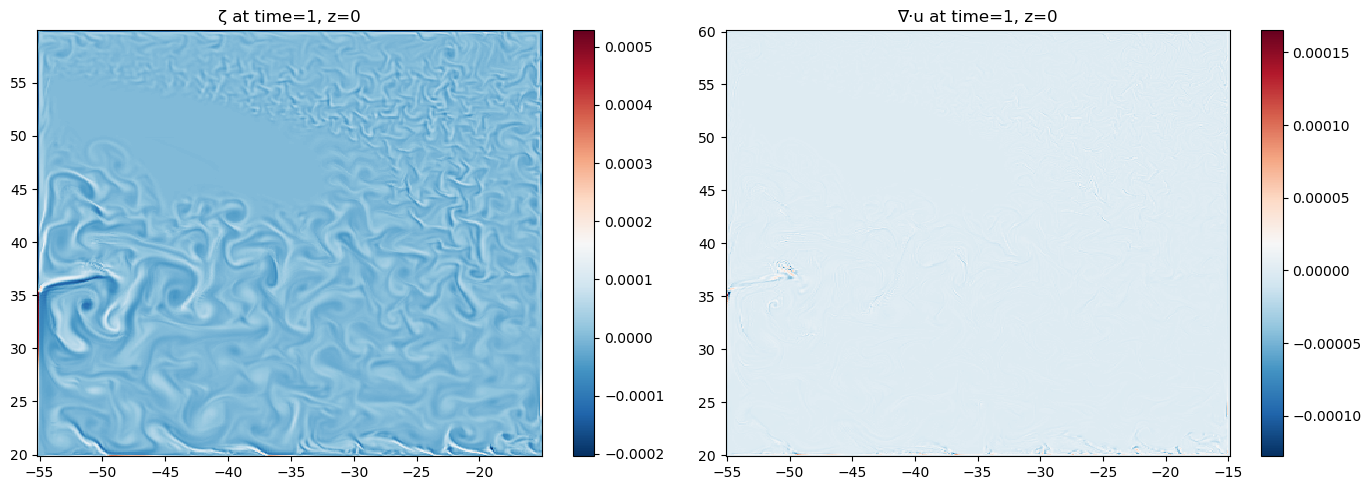

: 

In [ ]:
import xarray as xr
import matplotlib.pyplot as plt
from pathlib import Path

from div_and_vort_example import (
    build_mom6_grid_closed,
    infer_uniform_dx_dy_from_hgrid,
    mom6_vorticity_uniform,
    mom6_divergence_uniform,
    find_first_active_time,
)

# --- 1) Load data (adjust paths/year/month as needed)
base_dir = Path("/scratch/cimes/maximek/MOM6_Double_Gyre/DG-MOM6-COBALTv2/ice_ocean_SIS2/OM4_DG_COBALT")
year, month = 1960, 1
ds_bio = xr.open_dataset(base_dir / "MOM6COBALT_DG_JRA_60yr_raw" / f"hist_control_cobalt_3d_yearly__{year:04d}_{month:02d}.nc", chunks={"time": 1})
ds_phy = xr.open_dataset(base_dir / "MOM6COBALT_DG_JRA_60yr_raw" / f"hist_control_dynamics3d_yearly__{year:04d}_{month:02d}.nc", chunks={"time": 1})
ds_bc  = xr.open_dataset(base_dir / "MOM6COBALT_DG_JRA_60yr_raw" / f"hist_control_dynamics2d_yearly__{year:04d}_{month:02d}.nc", chunks={"time": 1})
ds_static = xr.open_dataset(base_dir / "hist_control_ocean_static.nc")
hgrid = xr.open_dataset(base_dir / "INPUT" / "DG_hgrid_011deg.nc")

ds = xr.merge([ds_bio, ds_phy, ds_bc, ds_static])

# --- 2) Metrics and grid
DX, DY = infer_uniform_dx_dy_from_hgrid(hgrid)
grid = build_mom6_grid_closed(ds)  # not strictly used in current stencil, but harmless

# --- 3) Compute vorticity/divergence
vort_3d = mom6_vorticity_uniform(ds, grid, DX=DX, DY=DY)
div_3d  = mom6_divergence_uniform(ds, grid, DX=DX, DY=DY)

ds_with_diagnostics = ds.assign(vorticity=vort_3d, divergence=div_3d)

# --- 4) Pick first active timestep (or override t0 manually)
t0 = find_first_active_time(ds, tol=1e-10)
k0 = 0  # surface

zeta_s = vort_3d.isel(time=t0, z_l=k0).compute()
div_s  = div_3d.isel(time=t0, z_l=k0).compute()

# --- 5) Quick plots
fig, axs = plt.subplots(1, 2, figsize=(14, 5))
im0 = axs[0].pcolormesh(zeta_s["xq"], zeta_s["yq"], zeta_s, shading="nearest", cmap="RdBu_r")
axs[0].set_title(f"ζ at time={t0}, z=0")
fig.colorbar(im0, ax=axs[0])

im1 = axs[1].pcolormesh(div_s["xh"], div_s["yh"], div_s, shading="nearest", cmap="RdBu_r")
axs[1].set_title(f"∇·u at time={t0}, z=0")
fig.colorbar(im1, ax=axs[1])
plt.tight_layout()


    base_dir = Path(
        "/scratch/cimes/maximek/MOM6_Double_Gyre/DG-MOM6-COBALTv2/"
        "ice_ocean_SIS2/OM4_DG_COBALT"
    )
    data_dir = base_dir / "MOM6COBALT_DG_JRA_60yr_raw"
    static_file = base_dir / "hist_control_ocean_static.nc"
    hgrid_file = base_dir / "INPUT" / "DG_hgrid_011deg.nc"

    year = 1960
    month = 1

    # -----------------------------------------------
    # File paths
    # -----------------------------------------------
    bio_file = data_dir / f"hist_control_cobalt_3d_yearly__{year:04d}_{month:02d}.nc"
    phy_file = data_dir / f"hist_control_dynamics3d_yearly__{year:04d}_{month:02d}.nc"
    bc_file  = data_dir / f"hist_control_dynamics2d_yearly__{year:04d}_{month:02d}.nc"

    print("Loading files:")
    print(f"  Bio:    {bio_file}")
    print(f"  Phy:    {phy_file}")
    print(f"  BC:     {bc_file}")
    print(f"  Static: {static_file}")
    print(f"  Hgrid:  {hgrid_file}")

    # -----------------------------------------------
    # Load datasets (chunk in time for Dask friendliness)
    # -----------------------------------------------
    ds_bio    = xr.open_dataset(bio_file, chunks={"time": 1})
    ds_phy    = xr.open_dataset(phy_file, chunks={"time": 1})
    ds_bc     = xr.open_dataset(bc_file,  chunks={"time": 1})
    ds_static = xr.open_dataset(static_file)
    hgrid     = xr.open_dataset(hgrid_file)

    print("\nLoaded hgrid:")
    print(hgrid)